<div style="text-align:center;">
  <h1 size=10>
    <b>DEEP LEARNING PROJECT</b><br>
    <b>WikiArt Painter Classification</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group XX**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Guilherme Silva (20221910)  
- Maria Carvalho (20221953)
- Maria Miguel Fonseca (20250380)

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Approach Overview](#1)
- [2. Set up & Imports](#2)
- [3. Load Dataset](#3)
- [4. Class Weights](#4)
- [5. Data Preprocessing](#5)
- [6. Modeling](#6)
    - [6.1 Basic Model Comparison](#6_1)
    - [6.2 Optimizer Comparison](#6_2)
    - [6.3 Activation Function Comparison](#6_3)
    - [6.4 Two-Phase Fine Tuning Experiments](#6_4)   
        - [6.4.1 Unfreezing Depth](#6_4_1)



# <font color='#2f94d7' size=6>**1. Approach Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=6>**2. Set up & Imports**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# IMPORT LIBRARIES
import os
import random
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from PIL import Image
import cv2
import pandas as pd

from pathlib import Path
import zipfile


import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers
from keras.applications import EfficientNetB0, VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3, EfficientNetV2S

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import shutil
import seaborn as sns

import gc
from keras.applications import VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3, EfficientNetV2S


# Import .py files
import sys
sys.path.append('/content/drive/MyDrive')
#from source.functions import *
from functions import *

In [3]:
# ── Unzip config ─────────────────────────────────────────────────────────────
ZIP_PATH   = Path('/content/drive/MyDrive/wikiart_split.zip')  # ajusta se necessário
EXTRACT_TO = Path('/content/wikiart_split')                     # disco local do Colab

if not EXTRACT_TO.exists():
    print('A extrair ZIP... (pode demorar 1-2 min na primeira vez)')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_TO.parent)
    print('Extração concluída!')
else:
    print('Pasta já existe, a saltar extração.')

Pasta já existe, a saltar extração.


In [4]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
# GENERAL CONFIGURATION
AUTOTUNE    = tf.data.AUTOTUNE
output_dir = "figures"

print('Keras  :', keras.__version__)
print('TF     :', tf.__version__)
print('GPU    :', tf.config.list_physical_devices('GPU') or 'None - CPU mode')

Keras  : 3.13.2
TF     : 2.19.0
GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# <font color='#2f94d7' size=6>**3. Load Dataset**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [6]:
# DATASET CONFIGURATION
IMG_SIZE    = (512, 512)   # Initial image size (can be adapted later for modeling)
NUM_CLASSES = 23
BATCH_SIZE  = 32

SPLIT_DIR      = Path('wikiart_split')
train_dir_path = SPLIT_DIR / 'train'
val_dir_path   = SPLIT_DIR / 'val'
test_dir_path  = SPLIT_DIR / 'test'

In [7]:
# LOAD DATASETS FROM THE SPLIT FOLDERS
# image_dataset_from_directory infers labels from subfolder names,
# guaranteeing consistent class_names order across machines.

train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir_path,
    label_mode='int', # integer labels for multi-class classification with class weights
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle = True,
    verbose=False
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    val_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

class_names = train_ds_raw.class_names

In [8]:
print(f"Class names: {class_names}")

# Check if labels are correctly inferred (int)
image, label = next(iter(train_ds_raw))
print("Image shape:", image.shape)   # (224, 224, 3)
print("Label:", label.numpy())
print("Class:", class_names[int(label)])

Class names: ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']
Image shape: (512, 512, 3)
Label: 15
Class: Pablo_Picasso


# <font color='#2f94d7' size=6>**4. Class Weights**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [9]:
# Compute class weights to handle class imbalance

# Extract labels from training dataset (convert one-hot → class index)
train_labels_flat = np.array([
    y.numpy() for _, y in train_ds_raw
])

# Compute balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_flat
)

# Convert to dictionary format required by Keras
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}

# Display classes with highest weights (rarest classes)
print("Class weights (top 5 heaviest):")
sorted_cw = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)

for idx, w in sorted_cw[:5]:
    print(f"  {class_names[idx]:<10}: {w:.3f}")

Class weights (top 5 heaviest):
  Salvador_Dali: 1.726
  Raphael_Kirchner: 1.599
  Ivan_Shishkin: 1.593
  Ilya_Repin: 1.531
  Childe_Hassam: 1.515


As expected, artists with fewer paintings receive higher class weights. This ensures that misclassifications on these underrepresented classes are penalized more during training, helping to reduce the impact of class imbalance.

# <font color='#2f94d7' size=6>**5. Data Preprocessing**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

In [10]:
# DEFINE AND APPLY DATA AUGMENTATION
base_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),       # ~ ±10°
    layers.RandomTranslation(0.03, 0.03),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.15),
], name="base_augmentation")

train_aug = (train_ds_raw
    .shuffle(10000, seed=SEED)
    .map(lambda x, y: (base_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))
# train_aug is not a dataset that is stored in memory, but a transformation pipeline applied on-the-fly to the training dataset.
# every time train_aug is iterated over, the base_augmentation transformations are applied to the images in train_ds_raw in a randomized manner, creating augmented versions of the images on-the-fly during training.
# loads 1000 samples into a shuffle buffer, shuffles them, and then applies the augmentation transformations to each batch of images as they are fed into the model during training.

In [11]:
# VISUALISE AUGMENTED TRAINING SAMPLES
sample_imgs, sample_labels = next(iter(train_aug.batch(8)))

print(sample_imgs.dtype)
print(tf.reduce_min(sample_imgs), tf.reduce_max(sample_imgs))

<dtype: 'float32'>
tf.Tensor(1.7893982, shape=(), dtype=float32) tf.Tensor(255.0, shape=(), dtype=float32)


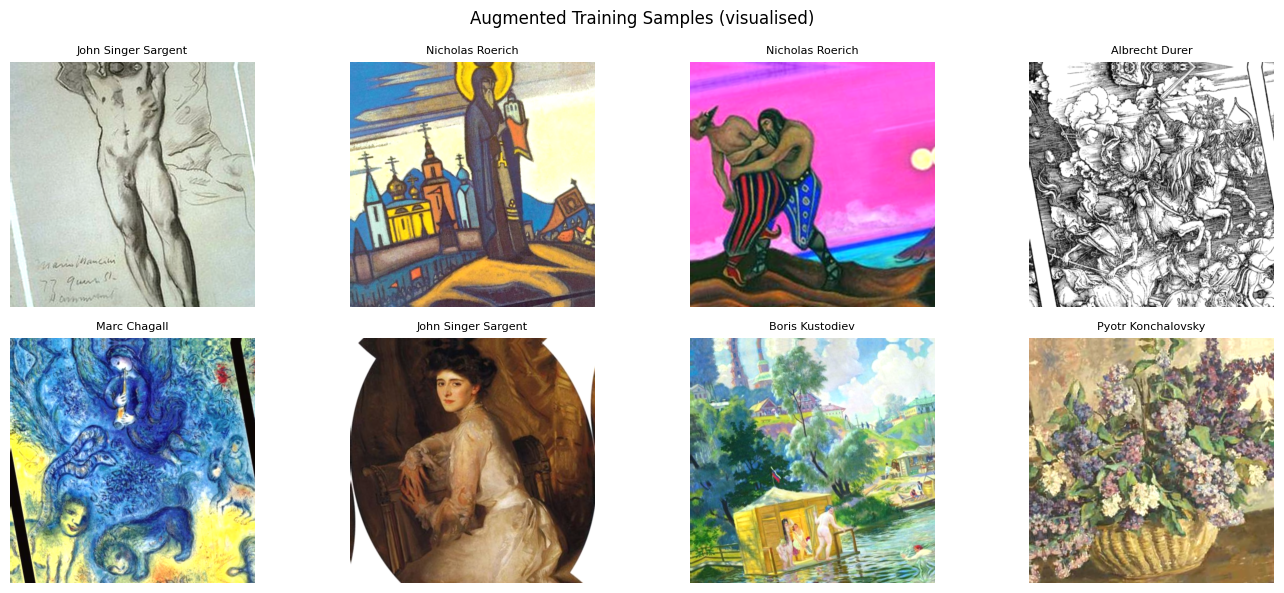

In [12]:
# imshow expects images in [0, 1] for floats, so we scale down the pixel values for visualization.
sample_display = sample_imgs.numpy() / 255.0

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, img, lbl in zip(axes.flatten(), sample_display, sample_labels):
    ax.imshow(img)
    ax.set_title(class_names[int(lbl)].replace('_', ' '), fontsize=8)  # ← int(lbl), não argmax
    ax.axis('off')

plt.suptitle('Augmented Training Samples (visualised)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "augmented_samples.png"), dpi=150)
plt.show()

In [13]:
# RESIZE DATASETS TO DIFFERENT SIZES
# we create separate resized datasets for each image size we want to experiment with during modeling.
train_224, val_224 = build_resized_ds(train_aug, val_ds_raw, 224, AUTOTUNE)
train_300, val_300 = build_resized_ds(train_aug, val_ds_raw, 300, AUTOTUNE)
train_384, val_384 = build_resized_ds(train_aug, val_ds_raw, 384, AUTOTUNE)
train_512 = train_aug
val_512 = val_ds_raw


In [14]:
# DEF PREPROCESSING FUNCTION FOR DIFFERENT MODELS
def apply_preprocess_ds(train_resized, val_resized, preprocess_fn, AUTOTUNE, batch_size=32):
    def apply_preprocess_img(image, label):
        image = preprocess_fn(image)
        return image, label

    t_ds = (train_resized
            .map(apply_preprocess_img, num_parallel_calls=AUTOTUNE)
            .batch(batch_size)
            .prefetch(AUTOTUNE))
    v_ds = (val_resized
            .map(apply_preprocess_img, num_parallel_calls=AUTOTUNE)
            .batch(batch_size)
            .prefetch(AUTOTUNE))
    return t_ds, v_ds

# <font color='#2f94d7' size=6>**6. Modeling**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

In [15]:
class SparseF1Score(keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # converte inteiros → one-hot antes de passar ao F1Score
        y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        return super().update_state(y_true_onehot, y_pred, sample_weight)

In [16]:
# METRICS - USED IN MODEL EVALUATION AND COMPARISON
def make_metrics():
    return [
        SparseF1Score(average='macro', name='macro_f1'),
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy'),
    ]

# <font color='#2f94d7' size=6>**6.1 Basic Model Comparison**</font> <a class="anchor" id="6_1"></a>

[Back to TOC](#toc)

To understand how architecture affects performance on artistic style classification, we compare **six backbones** using the same training pipeline (Phase 1 only — frozen backbone, identical head and hyperparameters).

| Backbone | Why include it? |
|---|---|
| **EfficientNetB0** | Our primary model — compound-scaled CNN, strong accuracy/size ratio |
| **VGG16** | Classic deep CNN — large but historically strong on texture/style tasks |
| **ResNet50V2** | Residual connections baseline — widely used reference point |
| **ConvNeXt-Tiny** | Modern pure-CNN (2022) — incorporates Transformer design ideas into a CNN, often outperforms EfficientNets |
| **EfficientNetB3** | More complex version of EfficientNetB0, expects 300x300 sized images|
| **EfficientNetV2S** | Expects 384x384 sized images, is more computanionally heavy, modern and should perform better than the other efficientNet options|


All models use ImageNet pretrained weights. We train only the classification head (frozen backbone) for a fixed number of epochs to ensure a fair comparison. For each backbone the model that will be selected will be the one with the smaller validation loss. Then to compare the backbones we will `val_macro_f1`, `val_top-3-accuracy` and overfit gap.  

We will use the class weights we defined earlier. In this initial phase of testing we will use a simple model (only one Dense intermideate layer) for efficiency and to check which models are more adequate for our data.

In [17]:
# BACKBONE CONFIGS - DEFINES THE BACKBONE MODELS, THEIR PREPROCESSING FUNCTIONS AND THE IMAGE SIZE THEY REQUIRE
BACKBONE_CONFIGS = {
    'EfficientNetB0': {
        'model_fn': EfficientNetB0,
        'preprocess': keras.applications.efficientnet.preprocess_input,
        'image_size': (224, 224),
        'train_ds': train_224,
        'val_ds': val_224
    },
    'EfficientNetB3': {
        'model_fn': EfficientNetB3,
        'preprocess': keras.applications.efficientnet.preprocess_input,
        'image_size': (300, 300),
        'train_ds': train_300,
        'val_ds': val_300
    },
    'EfficientNetV2S': {
        'model_fn': EfficientNetV2S,
        'preprocess': keras.applications.efficientnet_v2.preprocess_input,
        'image_size': (384, 384),
        'train_ds': train_384,
        'val_ds': val_384
    },
    'VGG16': {
        'model_fn': VGG16,
        'preprocess': keras.applications.vgg16.preprocess_input,
        'image_size': (224, 224),
        'train_ds': train_224,
        'val_ds': val_224
    },
    'ResNet50V2': {
        'model_fn': ResNet50V2,
        'preprocess': keras.applications.resnet_v2.preprocess_input,
        'image_size': (224, 224),
        'train_ds': train_224,
        'val_ds': val_224
    },
    'ConvNeXtTiny': {
        'model_fn': ConvNeXtTiny,
        'preprocess': keras.applications.convnext.preprocess_input,
        'image_size': (224, 224),
        'train_ds': train_224,
        'val_ds': val_224
    },
}

In [18]:
# PHASE 1 CONFIGURATION - INITIAL COMPARISON OF BACKBONES WITH FROZEN WEIGHTS AND SIMPLE HEAD
PHASE1_CONFIG = {
  'PHASE1_EPOCHS'    : 30,
  'PHASE1_LR'        : 1e-3,
  'ES_PATIENCE_P1'   : 7,
  'LR_FACTOR_P1'     : 0.3,
  'LR_PATIENCE_P1'   : 4,
  'LR_MIN_P1'        : 1e-6}

In [19]:
# CONFIGURATIONS FOR PHASE 2 - FINE-TUNING THE BEST BACKBONE WITH UNFROZEN WEIGHTS AND OPTIMISED HEAD
PHASE2_CONFIG = {
  'PHASE2_LR'         : 1e-5 ,
  'PHASE2_EPOCHS'     : 20  ,
  'ES_PATIENCE_P2'    : 6,
  'LR_FACTOR_P2'      : 0.3,
  'LR_PATIENCE_P2'    : 3,
  'LR_MIN_P2'         : 1e-7}

In [20]:
# ── Comparison loop ──────────────────────────────────────────────────────────
comparison_results = {}

for name, cfg in BACKBONE_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'  Training {name}')
    print(f'{"="*60}')

    model, backbone = build_base_model(name, backbone_configs=BACKBONE_CONFIGS, num_classes = NUM_CLASSES)
    train, val = apply_preprocess_ds(train_resized=cfg['train_ds'], val_resized=cfg['val_ds'], preprocess_fn=cfg['preprocess'], AUTOTUNE = AUTOTUNE, batch_size=BATCH_SIZE)

    # Model parameters
    n_params  = model.count_params()
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f'  Parameters : {n_params:,} total | {trainable:,} trainable')

    # Phase 1 only (frozen backbone)
    hist, _ = run_phase1(model, backbone, train, val, backbone_name=name, phase1_config = PHASE1_CONFIG,
                         phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

    # Save results
    metrics = extract_best_metrics(hist, prefix='p1')
    comparison_results[name] = {'params':    n_params, 'trainable': trainable, **metrics}

    r = comparison_results[name]
    print(f'  Overfitting gap (train F1 - val F1): {r["p1_overfit"]:.4f}')
    print(f'  Best val macro F1 : {r["p1_val_f1"]:.4f}')
    print(f'  Best val top-3    : {r["p1_val_top3"]:.4f}')
    print(f'  Min val loss      : {r["p1_val_loss"]:.4f}')

    # ── Free memory ─────────────────────────────────────────
    del model, backbone
    keras.backend.clear_session()
    gc.collect()


  Training EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
  Parameters : 4,388,538 total | 336,407 trainable
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 364ms/step - loss: 1.8072 - macro_f1: 0.4740 - top3_accuracy: 0.7112 - val_loss: 1.2545 - val_macro_f1: 0.6106 - val_top3_accuracy: 0.8271 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 250ms/step - loss: 1.1221 - macro_f1: 0.6426 - top3_accuracy: 0.8565 - val_loss: 1.1506 - val_macro_f1: 0.6514 - val_top3_accuracy: 0.8551 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 254ms/step - loss: 0.9023 - macro_f1: 0.7032 - top3_accuracy: 0.8931 - val_loss: 1.0770 - val_macro_f1: 0.6772 - val_top3_accuracy: 0.8716 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 251ms/step - loss: 0.7734 - macro_f1: 0.7392 - top3_accuracy: 0.9157 - val_loss: 1.0350 - val_macro_f1: 0.6827 - val_top3_accuracy: 0.8836 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 80

In [23]:
# Ver o que realmente existe no comparison_results
import pprint
pprint.pprint(comparison_results)

{'ConvNeXtTiny': {'p1_history': {'learning_rate': [0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0010000000474974513,
                                                   0.0003000000142492354,
                                                   0.0003000000142492354,
                                      

In [24]:
df_cmp = pd.DataFrame(comparison_results).T.reset_index().rename(columns={
    "index": "Backbone",
    "params": "Total Params",
    "trainable": "Trainable",
    "p1_train_f1": "Train Macro F1",
    "p1_val_f1": "Val Macro F1",
    "p1_val_top3": "Val Top-3",
    "p1_val_loss": "Val Loss",
    "p1_overfit": "F1 Gap"
})

df_cmp["F1 Gap"] = df_cmp["Train Macro F1"] - df_cmp["Val Macro F1"]
df_cmp = df_cmp.sort_values("Val Macro F1", ascending=False).reset_index(drop=True)

Dos gráficos a seguir ver o que faz ou não sentido manter

/tmp/ipykernel_7776/181206695.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_cmp["Backbone"], rotation=45, ha="right")
/tmp/ipykernel_7776/181206695.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_cmp["Backbone"], rotation=45, ha="right")


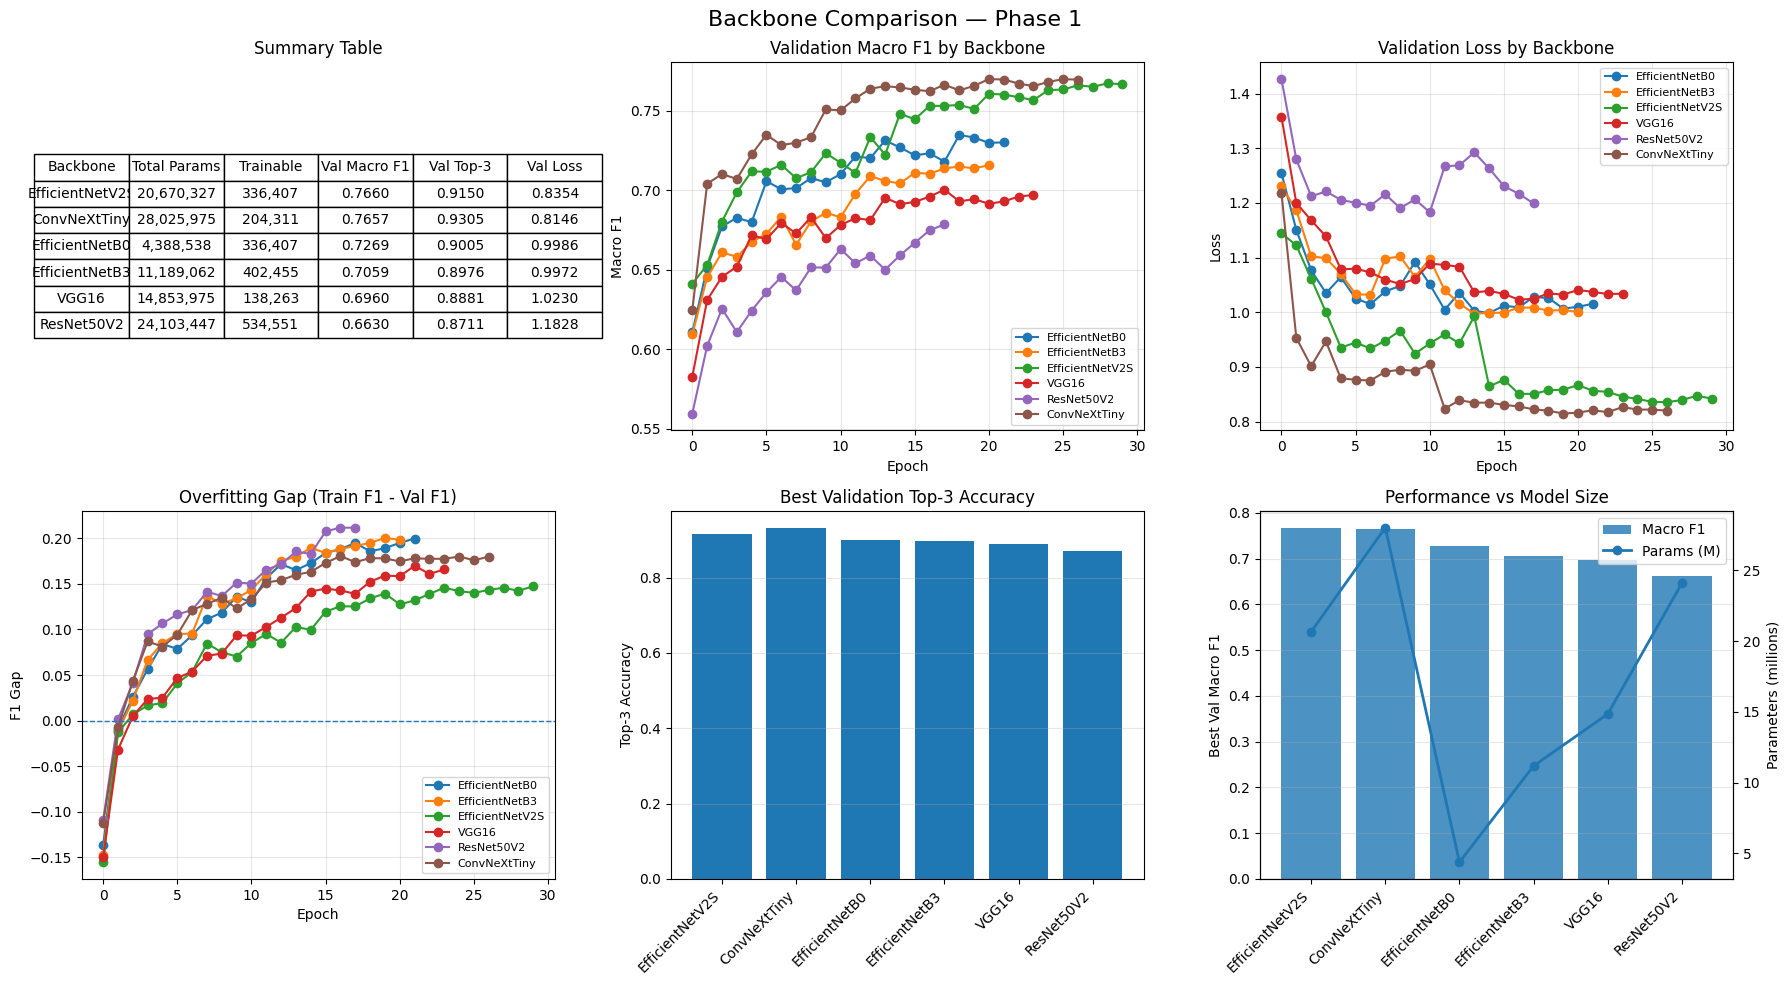

In [27]:
# ── Plot comparison dashboard ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Backbone Comparison — Phase 1", fontsize=16, y=0.98)

# -------------------- (1) Table --------------------
axes[0, 0].axis("off")

table_data = df_cmp[["Backbone", "Total Params", "Trainable", "Val Macro F1", "Val Top-3", "Val Loss"]].copy()
table_data["Total Params"] = table_data["Total Params"].map(lambda x: f"{x:,}")
table_data["Trainable"] = table_data["Trainable"].map(lambda x: f"{x:,}")
for col in ["Val Macro F1", "Val Top-3", "Val Loss"]:
    table_data[col] = table_data[col].map(lambda x: f"{x:.4f}")

tbl = axes[0, 0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center",
    cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
axes[0, 0].set_title("Summary Table", fontsize=12)

# -------------------- (2) Validation Macro F1 curves --------------------
ax = axes[0, 1]
for name, res in comparison_results.items():
    ax.plot(res["p1_history"]["val_macro_f1"], marker="o", label=name)
ax.set_title("Validation Macro F1 by Backbone")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# -------------------- (3) Validation Loss curves --------------------
ax = axes[0, 2]
for name, res in comparison_results.items():
    ax.plot(res["p1_history"]["val_loss"], marker="o", label=name)
ax.set_title("Validation Loss by Backbone")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# -------------------- (4) Overfitting gap curves --------------------
ax = axes[1, 0]
for name, res in comparison_results.items():
    train_f1 = np.array(res["p1_history"]["macro_f1"])
    val_f1   = np.array(res["p1_history"]["val_macro_f1"])
    gap = train_f1 - val_f1
    ax.plot(gap, marker="o", label=name)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Overfitting Gap (Train F1 - Val F1)")
ax.set_xlabel("Epoch")
ax.set_ylabel("F1 Gap")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# -------------------- (5) Best Val Top-3 bar chart --------------------
ax = axes[1, 1]
ax.bar(df_cmp["Backbone"], df_cmp["Val Top-3"])
ax.set_title("Best Validation Top-3 Accuracy")
ax.set_ylabel("Top-3 Accuracy")
ax.set_xticklabels(df_cmp["Backbone"], rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)

# -------------------- (6) Performance vs model size --------------------
ax = axes[1, 2]
bars = ax.bar(df_cmp["Backbone"], df_cmp["Val Macro F1"], alpha=0.8, label="Macro F1")
ax.set_ylabel("Best Val Macro F1")
ax.set_title("Performance vs Model Size")
ax.set_xticklabels(df_cmp["Backbone"], rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)

ax2 = ax.twinx()
ax2.plot(df_cmp["Backbone"], df_cmp["Total Params"] / 1e6, marker="o", linewidth=2, label="Params (M)")
ax2.set_ylabel("Parameters (millions)")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

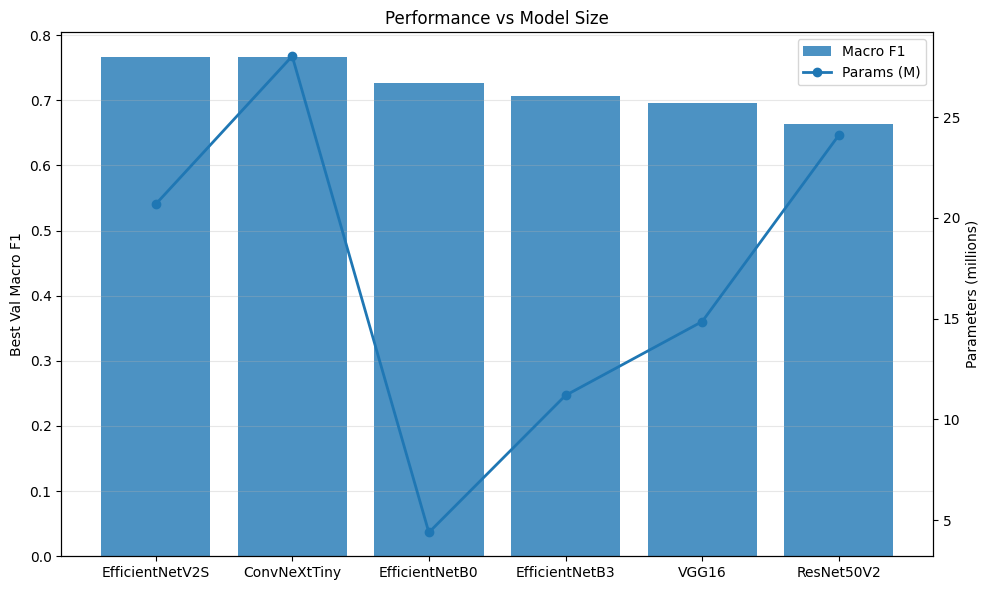

In [28]:
# GRÁFICO FINAL MAIOR MAIS ISOLADO - VER PELOS OUTPUTS QUAL PREFERIMOS
plt.figure(figsize=(10, 6))

ax = plt.gca()
ax.bar(df_cmp["Backbone"], df_cmp["Val Macro F1"], alpha=0.8, label="Macro F1")
ax.set_ylabel("Best Val Macro F1")
ax.set_title("Performance vs Model Size")
ax.grid(True, axis="y", alpha=0.3)

ax2 = ax.twinx()
ax2.plot(df_cmp["Backbone"], df_cmp["Total Params"] / 1e6, marker="o", linewidth=2, label="Params (M)")
ax2.set_ylabel("Parameters (millions)")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# <font color='#2f94d7' size=6>**6.2 Optmizer Comparison**</font> <a class="anchor" id="6_2"></a>

[Back to TOC](#toc)

In [ ]:
# ── Optimizer Comparison ─────────────────────────────────────────────────────
# Fixed backbone, same head, same resized dataset, same preprocessing, same callbacks.
# Only the optimizer changes.

OPT_BACKBONE = 'EfficientNetV2S'   # change here if you want another backbone
cfg = BACKBONE_CONFIGS[OPT_BACKBONE]

LION_LR = PHASE1_CONFIG['PHASE1_LR'] / 5   # Lion usually benefits from lower LR

OPTIMIZER_CONFIGS = {
    'Adam':    lambda: optimizers.Adam(learning_rate=PHASE1_CONFIG['PHASE1_LR']),
    'AdamW':   lambda: optimizers.AdamW(learning_rate=PHASE1_CONFIG['PHASE1_LR'], weight_decay=1e-4),
    'Lion':    lambda: optimizers.Lion(learning_rate=LION_LR, weight_decay=1e-4),
    'RMSprop': lambda: optimizers.RMSprop(learning_rate=PHASE1_CONFIG['PHASE1_LR'], rho=0.9),
}

In [ ]:
optimizer_results = {}

for opt_name in OPTIMIZER_CONFIGS:
    print(f'\n{"="*60}')
    print(f'  {OPT_BACKBONE} + {opt_name}')
    print(f'{"="*60}')

    model, bb = build_base_model(backbone_name = OPT_BACKBONE, backbone_configs=BACKBONE_CONFIGS, num_classes = NUM_CLASSES)
    train, val = apply_preprocess_ds(train_resized=cfg['train_ds'], val_resized=cfg['val_ds'], preprocess_fn=cfg['preprocess'],AUTOTUNE = AUTOTUNE, batch_size=BATCH_SIZE)

    # Phase 1 only (frozen backbone)
    hist, _ = run_phase1(model, bb, train, val, backbone_name=f"{OPT_BACKBONE}_{opt_name}", optimizer_fn = OPTIMIZER_CONFIGS[opt_name], phase1_config = PHASE1_CONFIG,
                         phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

    # Save results
    optimizer_results[opt_name] = extract_best_metrics(hist, prefix='p1')

    results = optimizer_results[opt_name]
    print(f'  Overfitting gap (train F1 - val F1): {results["p1_overfit"]:.4f}')
    print(f'  Best val macro F1 : {results["p1_val_f1"]:.4f}')
    print(f'  Best val top-3    : {results["p1_val_top3"]:.4f}')
    print(f'  Min val loss      : {results["p1_val_loss"]:.4f}')

    # Free memory
    del model, backbone
    keras.backend.clear_session()
    gc.collect()

print(f'\n{"="*60}')
print(f'  Activation function comparison complete ({OPT_BACKBONE})')
print(f'{"="*60}')


  EfficientNetV2S + Adam
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 212s 488ms/step - loss: 1.7706 - macro_f1: 0.4861 - top3_accuracy: 0.7242 - val_loss: 1.1989 - val_macro_f1: 0.6273 - val_top3_accuracy: 0.8506 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 309ms/step - loss: 1.1627 - macro_f1: 0.6393 - top3_accuracy: 0.8515 - val_loss: 1.1028 - val_macro_f1: 0.6541 - val_top3_accuracy: 0.8621 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 307ms/step - loss: 0.9838 - macro_f1: 0.6842 - top3_accuracy: 0.8833 - val_loss: 1.0417 - val_macro_f1: 0.6791 - val_top3_accuracy: 0.8721 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 307ms/step - loss: 0.8857 - macro_f1: 0.7054 - top3_accuracy: 0.9026 - val_loss: 0.9927 - val_macro_f1: 0.6796 - val_top3_accuracy: 0.8866 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 308ms/step - loss: 0.7697 - macro_f1: 0.7403 - top3_accuracy: 0.9166 - val_loss: 0.9702 - val_macro_

KeyboardInterrupt: 

In [ ]:
# ── Optimizer Comparison Results ────────────────────────────────────────────

print(f'\nOptimizer comparison for backbone: {OPT_BACKBONE}\n')
print(f'{"Optimizer":<20} {"Val Macro F1":>14} {"Val Top-3":>12} {"Val Loss":>10}')
print('-' * 58)
for name, r in sorted(optimizer_results.items(),
                       key=lambda x: x[1]['best_val_f1'], reverse=True):
    print(f'{name:<20} {r["best_val_f1"]:>14.4f} '
          f'{r["best_val_top3"]:>12.4f} {r["min_val_loss"]:>10.4f}')

In [ ]:
# ── Curvas: F1, Loss, Overfitting Gap ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for name, r in optimizer_results.items():
    epochs = range(1, len(r['history']['val_macro_f1']) + 1)
    axes[0].plot(epochs, r['history']['val_macro_f1'], label=name, linewidth=2)
    axes[1].plot(epochs, r['history']['val_loss'],     label=name, linewidth=2)

    gap = [tr - va for tr, va in zip(r['history']['macro_f1'],
                                      r['history']['val_macro_f1'])]
    axes[2].plot(epochs, gap, label=name, linewidth=2)

axes[0].set_title('Validation Macro F1 by Optimizer')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Macro F1')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss by Optimizer')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Overfitting Gap (Train − Val F1)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 Gap')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# <font color='#2f94d7' size=6>**6.3 Activation Function Comparison**</font> <a class="anchor" id="6_3"></a>

[Back to TOC](#toc)

In [ ]:
ACTIVATIONS = ['relu', 'gelu', 'swish', 'elu', 'leaky_relu']

ACT_BACKBONE = 'ConvNeXtTiny'
cfg = BACKBONE_CONFIGS[ACT_BACKBONE]

In [ ]:
activation_results = {}

for act_name in ACTIVATIONS:
    print(f'\n{"="*60}')
    print(f'  {ACT_BACKBONE} + {act_name}')
    print(f'{"="*60}')

    model, bb = build_base_model(backbone_name = ACT_BACKBONE, activation_name = act_name, backbone_configs = BACKBONE_CONFIGS,num_classes = NUM_CLASSES)
    train, val = apply_preprocess_ds(train_resized=cfg['train_ds'], val_resized=cfg['val_ds'], preprocess_fn=cfg['preprocess'], AUTOTUNE = AUTOTUNE, batch_size=BATCH_SIZE)

    # Phase 1 only (frozen backbone)
    hist, _ = run_phase1(model, bb, train, val, backbone_name=f"{ACT_BACKBONE}_{act_name}", phase1_config = PHASE1_CONFIG,
                         phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

    # Save results
    activation_results[act_name] = extract_best_metrics(hist, prefix='p1')

    results = activation_results[act_name]
    print(f'  Overfitting gap (train F1 - val F1): {results["p1_overfit"]:.4f}')
    print(f'  Best val macro F1 : {results["p1_val_f1"]:.4f}')
    print(f'  Best val top-3    : {results["p1_val_top3"]:.4f}')
    print(f'  Min val loss      : {results["p1_val_loss"]:.4f}')

    # Free memory
    del model, backbone
    keras.backend.clear_session()
    gc.collect()

print(f'\n{"="*60}')
print(f'  Activation function comparison complete ({ACT_BACKBONE})')
print(f'{"="*60}')

In [ ]:
# ── Activation Functions Comparison Results ────────────────────────────────

print(f'\nActivation function comparison for backbone: {ACT_BACKBONE}\n')
print(f'{"Activation function":<20} {"Val Macro F1":>14} {"Val Top-3":>12} {"Val Loss":>10}')
print('-' * 58)

for name, r in sorted(activation_results.items(),
                      key=lambda x: x[1]['best_val_f1'], reverse=True):
    print(f'{name:<20} {r["best_val_f1"]:>14.4f} '
          f'{r["best_val_top3"]:>12.4f} {r["min_val_loss"]:>10.4f}')

In [ ]:
# ── Curves: F1, Loss, Overfitting Gap ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for name, r in activation_results.items():
    epochs = range(1, len(r['history']['val_macro_f1']) + 1)

    axes[0].plot(epochs, r['history']['val_macro_f1'], label=name, linewidth=2)
    axes[1].plot(epochs, r['history']['val_loss'], label=name, linewidth=2)

    gap = [tr - va for tr, va in zip(r['history']['macro_f1'],
                                     r['history']['val_macro_f1'])]
    axes[2].plot(epochs, gap, label=name, linewidth=2)

axes[0].set_title('Validation Macro F1 by Activation Function')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Macro F1')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss by Activation Function')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Overfitting Gap (Train − Val F1)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Gap')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# <font color='#2f94d7' size=6>**6.4 Two-Phase Fine-Tuning Experiments**</font> <a class="anchor" id="6_4"></a>

[Back to TOC](#toc)

1. **Phase 1 — Feature Extraction**: Freeze the entire model backbone and train only the new classification head. This lets the head adapt without destroying pretrained weights.
2. **Phase 2 — Fine-tuning**: Unfreeze the top portion of the backbone and train end-to-end at a very low learning rate. This adapts higher-level features to the artistic domain.

# <font color='#2f94d7' size=5>**6.4.1 Unfreezing Depth**</font> <a class="anchor" id="6_4_1"></a>

[Back to TOC](#toc)

In this subsection, we evaluate different numbers of layers to unfreeze during the fine-tuning stage. Unfreezing too many layers may excessively alter the pre-trained weights, while unfreezing too few may prevent the model from adequately adapting to the specific characteristics of our dataset.

In [ ]:
UNFREEZE_CANDIDATES = [50, 30, 10, 5] # number of last layers to unfreeze in the backbone for fine-tuning, we will experiment with different values to find the best balance between performance and overfitting risk.
TOP2_BACKBONES = ['ConvNeXtTiny', 'EfficientNetB0']

In [ ]:
unfreeze_results = {}

for backbone_name in TOP2_BACKBONES:
    print(f'\n{"="*60}\n  {backbone_name}\n{"="*60}')

    model, backbone = build_base_model(backbone_name, backbone_configs = BACKBONE_CONFIGS, num_classes = NUM_CLASSES)
    cfg = BACKBONE_CONFIGS[backbone_name]
    train, val = apply_preprocess_ds(train_resized=cfg['train_ds'], val_resized=cfg['val_ds'], preprocess_fn=cfg['preprocess'], batch_size=BATCH_SIZE)

    # Phase 1
    hist_p1, phase1_weights = run_phase1(model, backbone, train, val, backbone_name, phase1_config = PHASE1_CONFIG,
                         phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

    # Phase 2
    for n_unfreeze in UNFREEZE_CANDIDATES:
        exp_name = f"{backbone_name}_unfreeze{n_unfreeze}"
        hist_p2  = run_phase2(model, backbone, train, val, phase1_weights, backbone_name, n_unfreeze, phase1_config = PHASE1_CONFIG, phase2_config = PHASE2_CONFIG, make_metrics = make_metrics, class_weight_dict = class_weight_dict)

        unfreeze_results[exp_name] = {
            'backbone':   backbone_name,
            'n_unfreeze': n_unfreeze,
            **extract_best_metrics(hist_p1, prefix='p1'),
            **extract_best_metrics(hist_p2, prefix='p2'),
        }

        r = unfreeze_results[exp_name]
        print(f'\n  {exp_name}')
        print(f'  Phase 1 → Val F1 : {r["p1_val_f1"]:.4f}')
        print(f'  Phase 2 → Val F1 : {r["p2_val_f1"]:.4f}')
        print(f'  Phase 2 → Top-3  : {r["p2_val_top3"]:.4f}')
        print(f'  Overfitting gap  : {r["p2_overfit"]:.4f}')

    del model, backbone
    keras.backend.clear_session()
    gc.collect()

# <font color='#2f94d7' size=6>**7 Fine-Tuning (Unfreeze Top Layers)**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)